## **Data Understanding**

### Load Dataset & Cek Struktur Data 

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('../data/raw/Student_performance_data.csv')
%store df

# Cek dimensi data
print("Dimensi Data:")
print(f"Baris: {df.shape[0]} | Kolom: {df.shape[1]}")

# Tampilkan 5 baris pertama
print("\nPreview Data (5 Baris Pertama):")
print(df.head())

# Cek tipe data tiap kolom
print("\nTipe Data Tiap Kolom:")
print(df.dtypes)

Stored 'df' (DataFrame)
Dimensi Data:
Baris: 2392 | Kolom: 15

Preview Data (5 Baris Pertama):
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   

### Cek Missing Values

In [2]:
# # Cek missing values
print("Missing Values per Kolom:")
print(df.isnull().sum())

# Total missing values
total_missing = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

Missing Values per Kolom:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Total Missing Values: 0


### Statistical Summary

In [3]:
# Statistik deskriptif
print("Statistik Deskriptif (Kolom Numerik):")
print(df.describe())

Statistik Deskriptif (Kolom Numerik):
         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.46741

### Distribusi Target Variable (GradeClass)

C:\Users\MacTavish\AppData\Local\Temp\ipykernel_13504\3681334275.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_dist.index, y=grade_dist.values, palette='viridis')


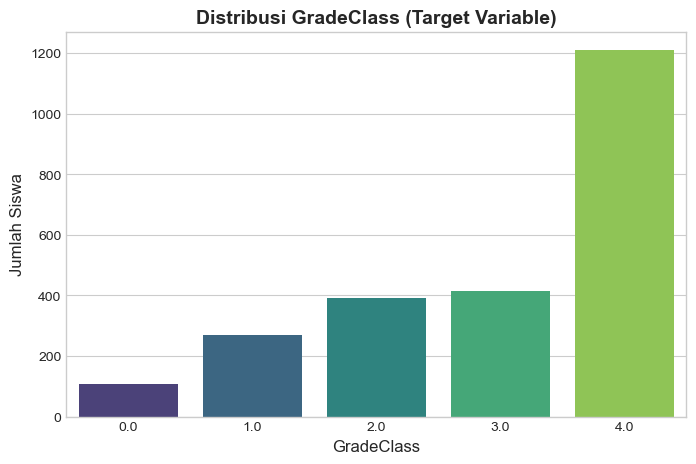

Distribusi GradeClass:
   Grade 0.0: 107 siswa (4.5%)
   Grade 1.0: 269 siswa (11.2%)
   Grade 2.0: 391 siswa (16.3%)
   Grade 3.0: 414 siswa (17.3%)
   Grade 4.0: 1211 siswa (50.6%)


In [4]:
# Import matplotlib & seaborn untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Atur style visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Hitung distribusi GradeClass
grade_dist = df['GradeClass'].value_counts().sort_index()

# Visualisasi bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=grade_dist.index, y=grade_dist.values, palette='viridis')
plt.title('Distribusi GradeClass (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('GradeClass', fontsize=12)
plt.ylabel('Jumlah Siswa', fontsize=12)
plt.xticks([0, 1, 2, 3, 4])
plt.show()

# Tampilkan count & persentase
print("Distribusi GradeClass:")
for grade, count in grade_dist.items():
    pct = (count / len(df)) * 100
    print(f"   Grade {grade}: {count} siswa ({pct:.1f}%)")

### Korelasi Awal dengan Target

C:\Users\MacTavish\AppData\Local\Temp\ipykernel_13504\2171486824.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


Korelasi Fitur dengan GradeClass:
GradeClass           1.000000
Absences             0.728633
ParentalEducation    0.041031
Gender               0.022998
Volunteering         0.013156
Age                 -0.006250
Ethnicity           -0.023326
Sports              -0.026654
Music               -0.036065
Extracurricular     -0.069733
StudentID           -0.098500
Tutoring            -0.111695
StudyTimeWeekly     -0.134131
ParentalSupport     -0.136823
GPA                 -0.782835
Name: GradeClass, dtype: float64


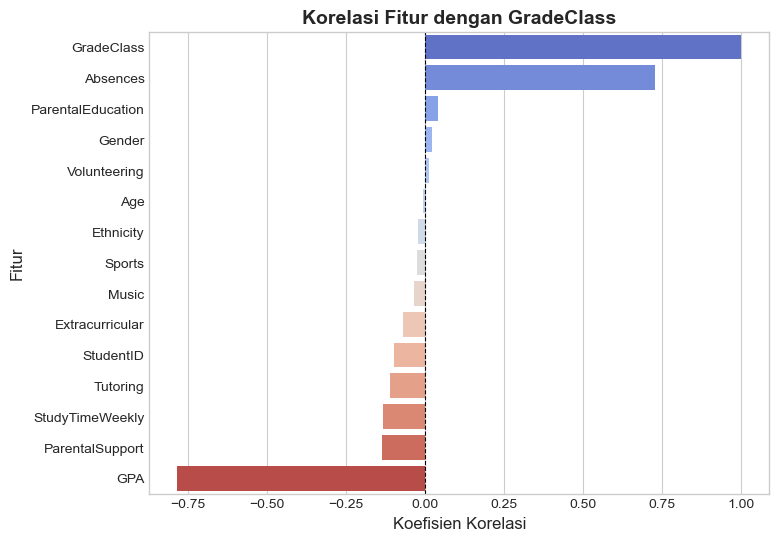

In [5]:
# Hitung korelasi antar fitur numerik
corr_matrix = df.corr(numeric_only=True)

# Korelasi dengan target variable
target_corr = corr_matrix['GradeClass'].sort_values(ascending=False)

print("Korelasi Fitur dengan GradeClass:")
print(target_corr)

# Visualisasi korelasi dengan GradeClass
plt.figure(figsize=(8, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Korelasi Fitur dengan GradeClass', fontsize=14, fontweight='bold')
plt.xlabel('Koefisien Korelasi', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.show()

**Insight Awal:**
- **StudyTimeWeekly** & GPA memiliki korelasi negatif kuat dengan GradeClass (semakin tinggi waktu belajar/GPA, semakin rendah GradeClass → Grade 0 = nilai terbaik).
- **Absences** juga berkorelasi negatif (semakin banyak absensi, semakin buruk nilai).
- *Catatan:* GradeClass 0 = A (terbaik), 4 = E (terburuk) berdasarkan pola data.